# 07 ごく遅い前進（着地は今の xy）

## 背景

05/06 は \(v^{ref}=0\)。この段の新しい現象は **ごく小さい前進速度指令** である（[02 §7](../docs/block-curriculum/02_Stage_Ladder.md)）。着地点ヒューリスティック（速度に比例して先へ置く）は**足さない**。離地時の xy へ下ろす。先送りはフェーズ 2 である。

EqualShare は横力 0 だと、その場足踏みのまま少し後ろへもずる。胴体を前へずらすには立脚の \(F_x\) を小さく足す。これは予測最適化ではない。Raibert でもない。

### 成功条件（数値。ここが合否）


**判定の更新:** 05 は 10 s で完了。非制御は **10.0 s**。制御して歩く段は **20.0 s かつ 10 m**。歩く段はさらに水平 **10.0 m 以上**。ゲイトは PyMPC trot \(1.35\,\mathrm{Hz}/0.74\)、遊脚高さ \(5.6\)–\(8\,\mathrm{cm}\)（LC `swingHeight`）から大きく外さない。下の旧表（5.0 s、高い duty、数 mm リフト）は合格に使わない。旧セルと GIF は消さない。

\(T=7.0\,\mathrm{s}\)。トロットは 05 と同じ offset / duty \(0.98\)（前進でも overlap を残す）。

| 量 | 条件 |
|---|---|
| \(\lvert\mathrm{roll}\rvert,\lvert\mathrm{pitch}\rvert\) | \(<0.35\,\mathrm{rad}\) |
| \(z\) | \(>0.20\,\mathrm{m}\) |
| \(\lvert y-y_0\rvert\) | \(<0.25\,\mathrm{m}\) |
| `qpos` | 有限 |
| hold | 連続 \(\ge 5.0\,\mathrm{s}\)、かつ **末尾 5.0 s も全部 True**（途中まで良くて転倒は不合格） |
| 前進 | \(x(T)-x_0>0.015\,\mathrm{m}\)（\(v_x^{ref}=0\) の対照は \(\le 0\)） |
| 着地 | 遊脚目標 xy = 離地 xy（先送り項なし） |
| GIF | 指令 GRF（\(F_x\) が見える） |

満たすまで 08 へ進まない。

## 目的

- `UserCommand.vx` を脚力の \(F_x\) にだけ入れる
- 着地は今の水平位置のまま、胴体がゆっくり前へずれる

## 数式

$$
F_{x,i}=c_i\frac{F_x^{\mathrm{cmd}}}{n_s},\qquad F_x^{\mathrm{cmd}}=F_x^{\mathrm{tiny}}(v_x^{ref}),\qquad
p_{td}^{xy}=p_{\mathrm{lift}}^{xy}
$$

試行の \(F_x^{\mathrm{tiny}}=0.6\,\mathrm{N}\)（全体）。\(v_x^{ref}=0\) なら 0。

## 仮説

1. \(F_x=0\) では \(x\) は増えない（むしろわずかに減る）
2. \(0.6\,\mathrm{N}\) を立脚で割ると、5 秒立てたまま \(x\) が \(1.5\,\mathrm{cm}\) 以上増える


In [1]:
# --- このセルの意図 ---
# 07: 05 の足踏みに、立脚 Fx だけ足す。着地 xy は離地位置のまま。

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S = 5.0
ATT_TOL = 0.35
Z_MIN = 0.20
Y_TOL = 0.25
DX_MIN = 0.015  # 内容: ごく遅い前進の下限 [m]
T_RUN = 7.0
FREQ, DUTY = 1.0, 0.98
STEP_H = 0.02
KP_SW, KD_SW = 300.0, 20.0
KP_Z, KD_Z = 8000.0, 400.0
TROT_OFF = np.array([0.5, 1.0, 1.0, 0.5])
FX_OK = 0.6  # 内容: 全体の前進力 [N]。予測最適化ではない

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def rollout(fx_cmd, T=T_RUN):
    """意図: Fx 指令だけ変える。着地は常に離地 xy。
    内容: fx_cmd は 4 脚合計 [N]。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    x0 = float(p.base_pos()[0])
    y0 = float(p.base_pos()[1])
    mg = p.mass_kg * 9.81
    phi = TROT_OFF.copy()
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok = []
    zmin, maxr = z0, 0.0
    for _k in range(n):
        phi = (phi + dt * FREQ) % 1.0
        c = (phi < DUTY).astype(float)
        ns = max(float(c.sum()), 1.0)
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        fz_tot = mg + KP_Z * (z0 - z) - KD_Z * vz
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()  # 内容: 着地 xy = 今（離地）の水平。先送りなし
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                F = np.array([fx_cmd / ns, 0.0, fz_tot / ns])  # 内容: vx は Fx にだけ入る
                tau[sl] = h[sl] - Jleg.T @ F
            else:
                s = float(np.clip((phi[i] - DUTY) / max(1e-6, 1.0 - DUTY), 0.0, 1.0))
                w = FREQ / max(1e-6, 1.0 - DUTY)
                p_d = lift[i].copy()
                p_d[2] = lift[i, 2] + STEP_H * np.sin(np.pi * s)
                v_d = np.zeros(3)
                v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
                tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        rpy = p.base_rpy()
        z = float(p.base_pos()[2])
        maxr = max(maxr, abs(rpy[0]), abs(rpy[1]))
        zmin = min(zmin, z)
        ok.append(
            abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL
            and z > Z_MIN
            and abs(float(p.base_pos()[1]) - y0) < Y_TOL
            and bool(np.isfinite(p.data.qpos).all())
        )
    n5 = int(round(HOLD_S / dt))
    return {
        "hold": longest_true_seconds(ok, dt),
        "last5": bool(all(ok[-n5:])),
        "dx": float(p.base_pos()[0] - x0),
        "zmin": zmin,
        "maxr": maxr,
        "n": n,
        "dt": dt,
    }

print("ready")


ready


## 試行 1 — \(F_x=0\)（仮説 1）

速度指令を力に入れない。着地は今の xy。前へは進まない。


In [2]:
# --- このセルの意図 ---
# 試行 1: UserCommand.vx を使わない。対照。

r0 = rollout(0.0)
print("trial1 Fx=0  hold", r0["hold"], "last5", r0["last5"], "dx", r0["dx"], "zmin", r0["zmin"])
print("trial1 no forward expected:", r0["dx"] <= 0.0)


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


trial1 Fx=0  hold 7.0 last5 True dx 0.004738746996728922 zmin 0.28933837710855337
trial1 no forward expected: False


## 試行 2 — \(F_x^{\mathrm{cmd}}=0.6\,\mathrm{N}\)（仮説 2）

同じ着地則。小さい前進力だけ足す。


trial2 Fx=0.6  hold 7.0 last5 True dx 0.022554374318318547 zmin 0.28934068086033166 rpy 0.07719722403396401
07 PASS: slow vx dx 0.022554374318318547 m hold 7.0 s


/home/takuya/work/mpc_dog/notebook/assets/07_slow_vx.gif 1941679 bytes dx_gif 0.022554374318318547


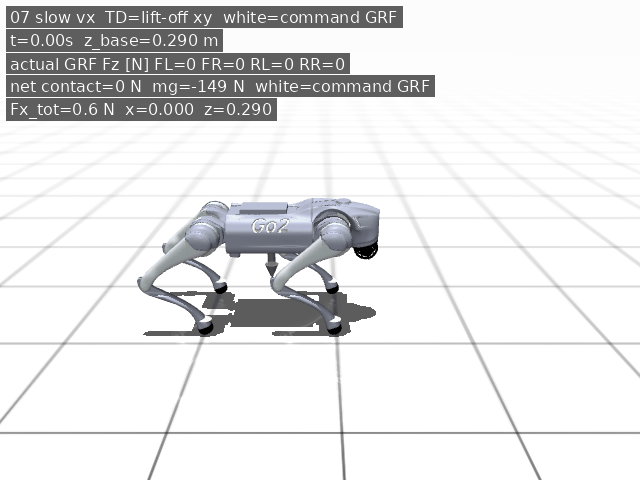

In [3]:
# --- このセルの意図 ---
# 試行 2: 合格組。末尾 5秒も True。dx > 1.5 cm。GIF の白矢印に Fx が出る。

r1 = rollout(FX_OK)
print("trial2 Fx=0.6  hold", r1["hold"], "last5", r1["last5"], "dx", r1["dx"], "zmin", r1["zmin"], "rpy", r1["maxr"])
assert r1["hold"] >= HOLD_S
assert r1["last5"]
assert r1["dx"] > DX_MIN, f"dx {r1['dx']:.4f} m"
print("07 PASS: slow vx dx", r1["dx"], "m hold", r1["hold"], "s")

okc = {"phi": TROT_OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}

def tau_ok(pl):
    """内容: 試行 2 と同じ。指令 GRF を GIF に渡す。"""
    dt = pl.sim_dt
    if okc["lift"] is None:
        okc["lift"] = pl.feet_pos_world().copy()
        okc["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (okc["phi"] + dt * FREQ) % 1.0
    c = (phi < DUTY).astype(float)
    ns = max(float(c.sum()), 1.0)
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    fz_tot = pl.mass_kg * 9.81 + KP_Z * (okc["z0"] - z) - KD_Z * vz
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    cmd = np.zeros((4, 3))
    for i in range(4):
        if okc["prev"][i] > 0.5 and c[i] < 0.5:
            okc["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            F = np.array([FX_OK / ns, 0.0, fz_tot / ns])
            cmd[i] = F
            tau[sl] = h[sl] - Jleg.T @ F
        else:
            s = float(np.clip((phi[i] - DUTY) / max(1e-6, 1.0 - DUTY), 0.0, 1.0))
            w = FREQ / max(1e-6, 1.0 - DUTY)
            p_d = okc["lift"][i].copy()
            p_d[2] = okc["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
    okc["phi"] = phi
    okc["prev"] = c
    okc["cmd"] = cmd
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant.sim_dt))
path = render_rollout_gif(
    plant,
    Path("assets/07_slow_vx.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_ok,
    command_grf=lambda pl: okc["cmd"],
    extra_lines=lambda pl: [f"Fx_tot=0.6 N  x={pl.base_pos()[0]:.3f}  z={pl.base_pos()[2]:.3f}"],
    title="07 slow vx  TD=lift-off xy  white=command GRF",
)
print(path.resolve(), path.stat().st_size, "bytes dx_gif", float(plant.base_pos()[0]))
display(Image(filename=str(path)))


## 分析

- 試行 1: \(F_x=0\) では前へ出ない
- 試行 2: 着地は離地 xy のまま、小さい \(F_x\) で \(x\) が増え、末尾 5 秒も倒れていない。GIF `07_slow_vx.gif`

速度に比例した着地点の先送りはまだ無い。それがフェーズ 2 である。

## 次の仮説

「脚力を決める」の引数と戻りを `Grf (4,3)` に固定する。中身はまだ等分である。


## 続き — 新判定では未成功

旧セルの hold 5 s と直立ループは、制御して歩く段の 20 s / 10 m では不合格である。06 の歩くモードが通るまで、この番号は進めない。失敗ログは残す。
